# Dutch: Results ver

## Libraries and stuff

In [ ]:
import os
import json
import yaml
import random
import time
import functools
import pickle
import re
import orjson
import alibi
import ignite
import copy

from IPython import display
from itertools import combinations, product
from tqdm import tqdm
from matplotlib import pyplot as plt
from collections import Counter
import seaborn as sns
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.optim as optimizer


from torchsummary import summary
from torch.utils.data import TensorDataset, DataLoader
from pathlib import Path

from bridget_utils import *



c:\Users\virgm\anaconda3\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


26-Mar-26 15:58:55 fatf.utils.array.tools INFO     Using numpy's numpy.lib.recfunctions.structured_to_unstructured as fatf.utils.array.tools.structured_to_unstructured and fatf.utils.array.tools.structured_to_unstructured_row.


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
ds_name='dutch'

## Expert: Accurate, Trusting

### Iter 1

In [4]:
iter = 1
user_name= 'accurate_trusting'

hic_metrics= ['ARF_Accuracy', 'ARF_F1', 'ARF_HiC_FEA_machine', 'ARF_HiC_FEA_user', 'ARF_Machine_Confidence']
mic_metrics= ['Def_Net_Model_FEA', 'Def_Net_System_FEA']

#### HIC

In [5]:
acc_t_iter_1= get_hic_data(ds_name, iter, user_name, hic_metrics)


In [6]:
acc_t_iter_1


,ARF_Accuracy,ARF_F1,ARF_HiC_FEA_machine,ARF_HiC_FEA_user,ARF_Machine_Confidence
idx,,,,,
0,0.721800,0.717520,1.000000,0.000000,0.522210
1,0.721800,0.717520,0.995000,0.000000,0.549259
2,0.720716,0.716418,0.656700,0.333333,0.596123
3,0.719631,0.715394,0.737600,0.497500,0.777304
4,0.719089,0.714728,0.784179,0.594020,0.510752
...,...,...,...,...,...
2454,0.712581,0.704442,0.029628,0.029178,0.827739
2455,0.713124,0.705377,0.029320,0.029281,0.605199
2456,0.713666,0.705881,0.029422,0.029384,0.813704


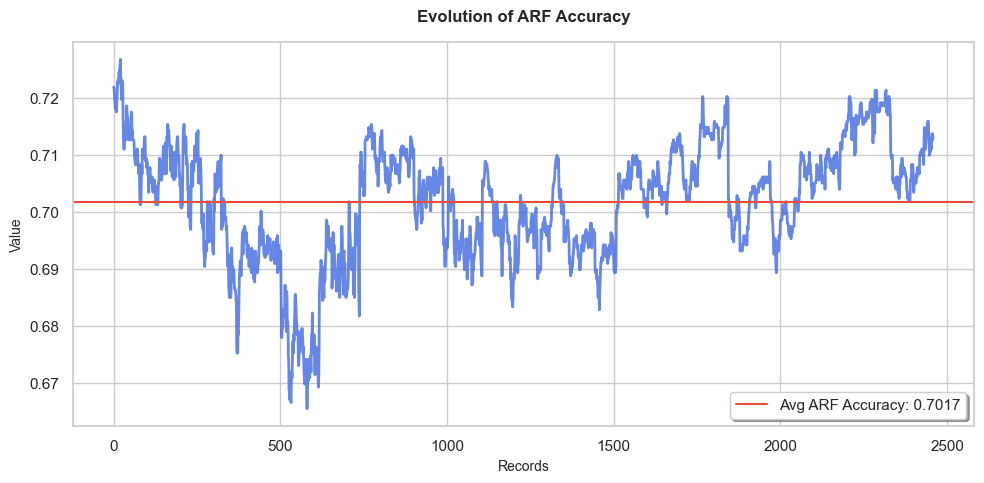

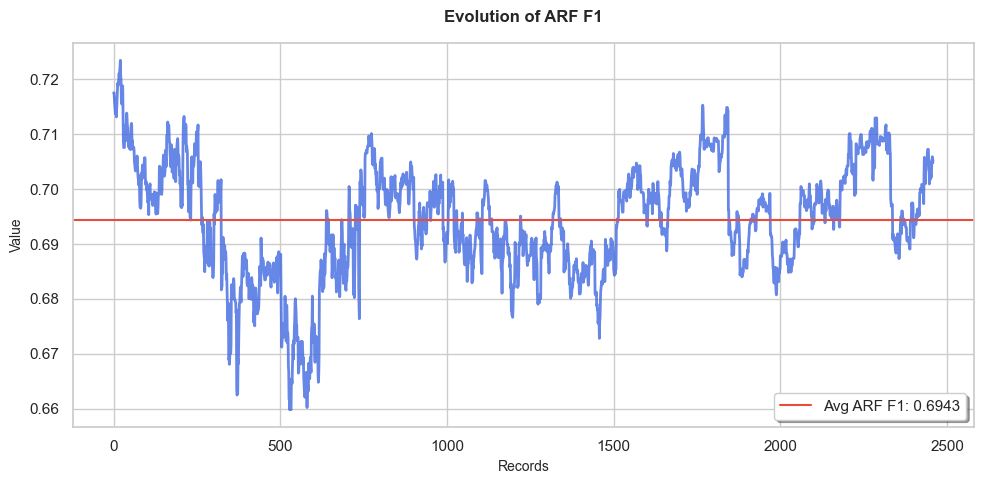

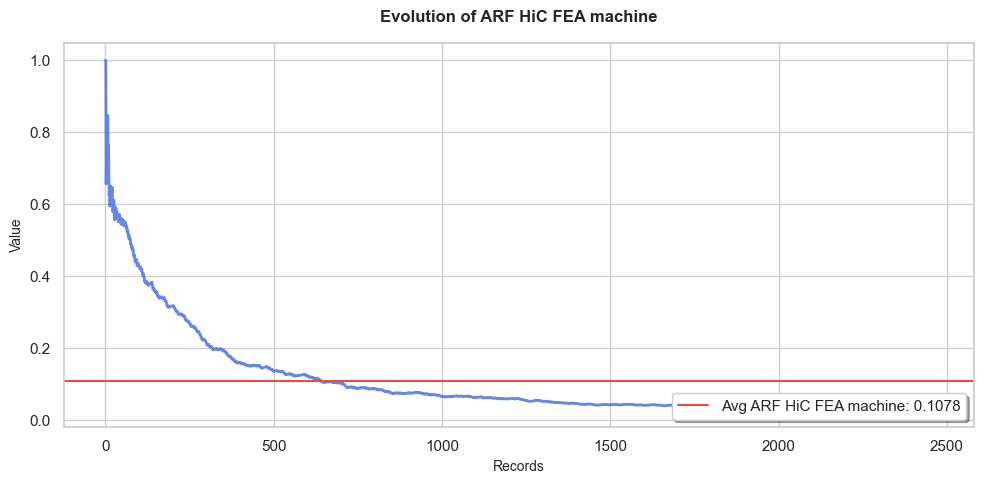

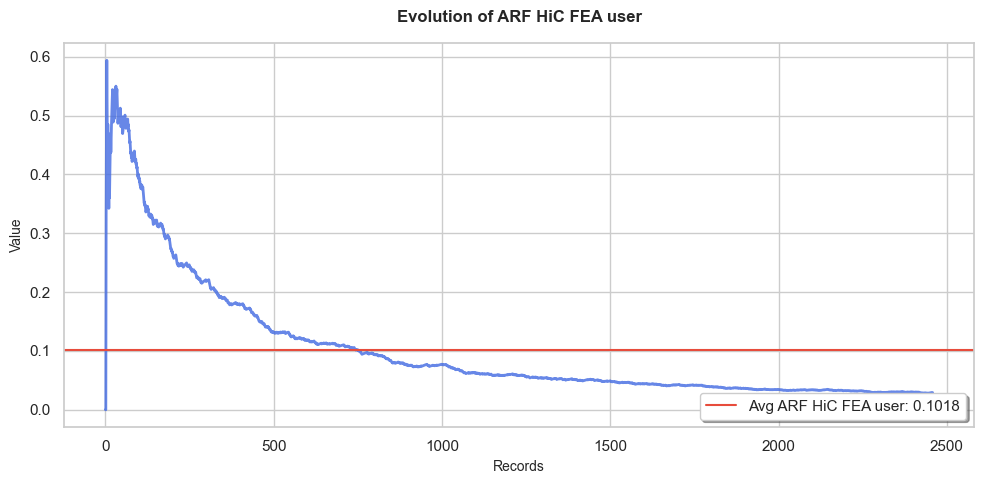

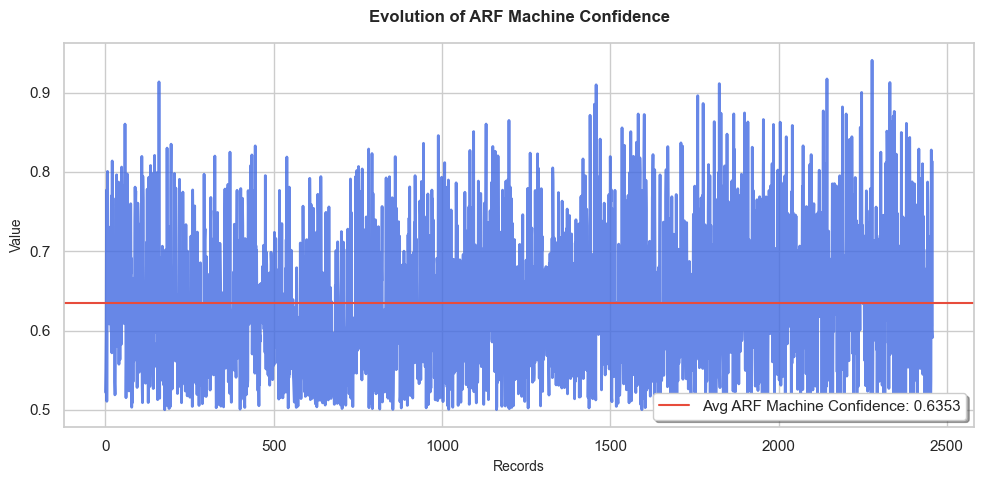

In [7]:
plot_sns(acc_t_iter_1, hic_metrics, mean_required=True)

#### MIC Confidence Strat

In [30]:
strategy= 'Confidence'
beta= 'None'
acc_t_mic_conf= get_mic_data(ds_name, iter, user_name, strategy, beta, mic_metrics)


In [31]:
acc_t_mic_conf

,Def_Net_Model_FEA,Def_Net_System_FEA
idx,,
0,0.000000,0.000000
1,0.502513,0.502513
2,0.670011,0.670011
3,0.499975,0.499975
4,0.397960,0.397960
...,...,...
3683,0.630577,0.630577
3684,0.624271,0.624271
3685,0.628028,0.628028


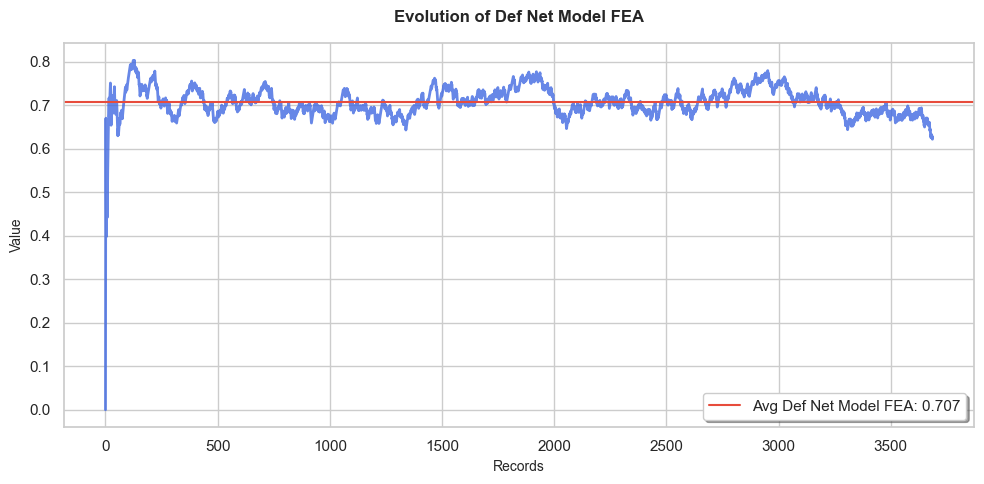

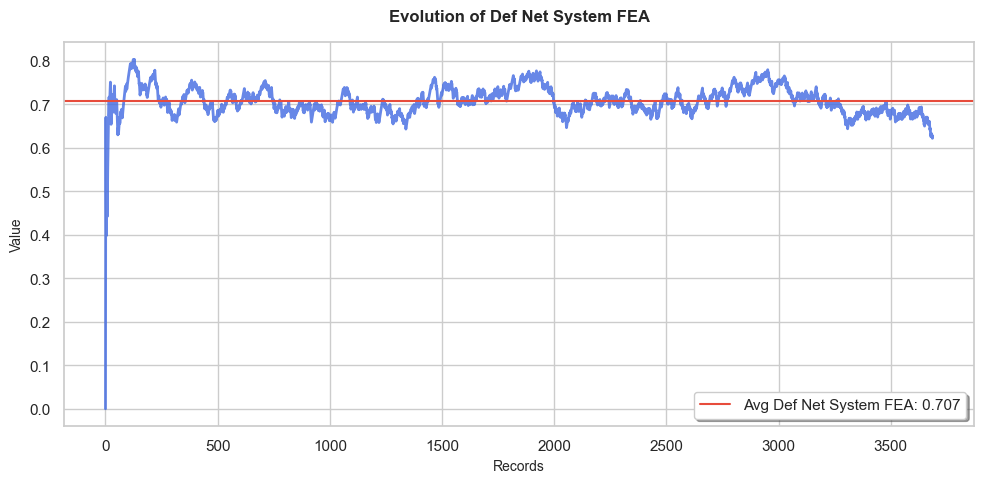

In [28]:
plot_sns(acc_t_mic_conf, mic_metrics, mean_required=True)

#### MiC Two Stage Deferral Strat

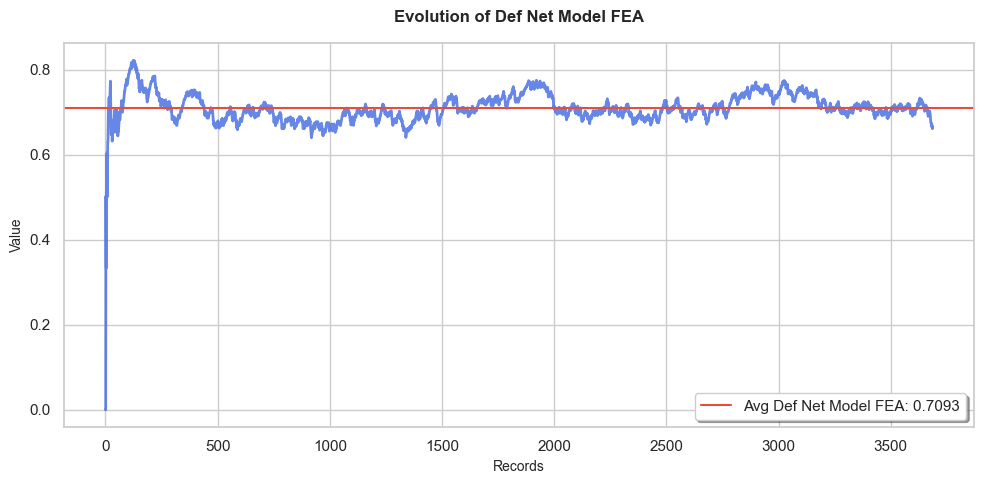

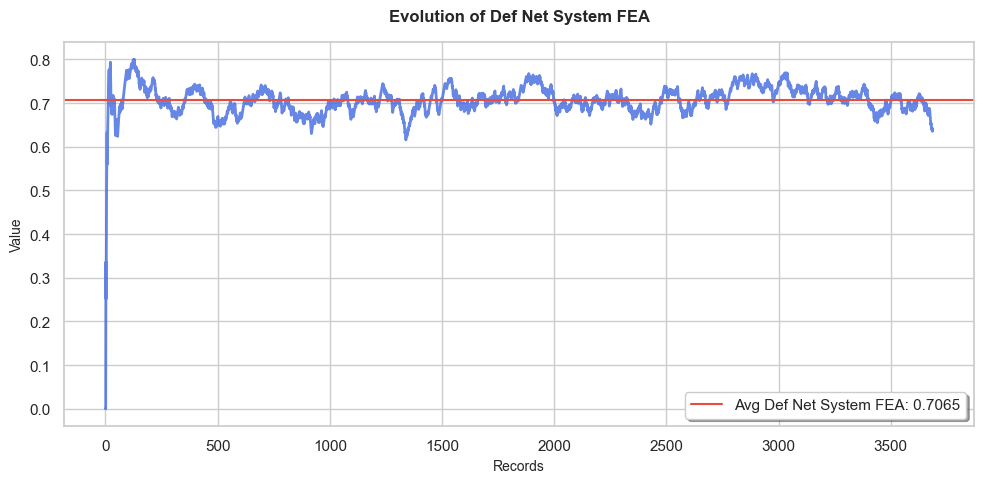

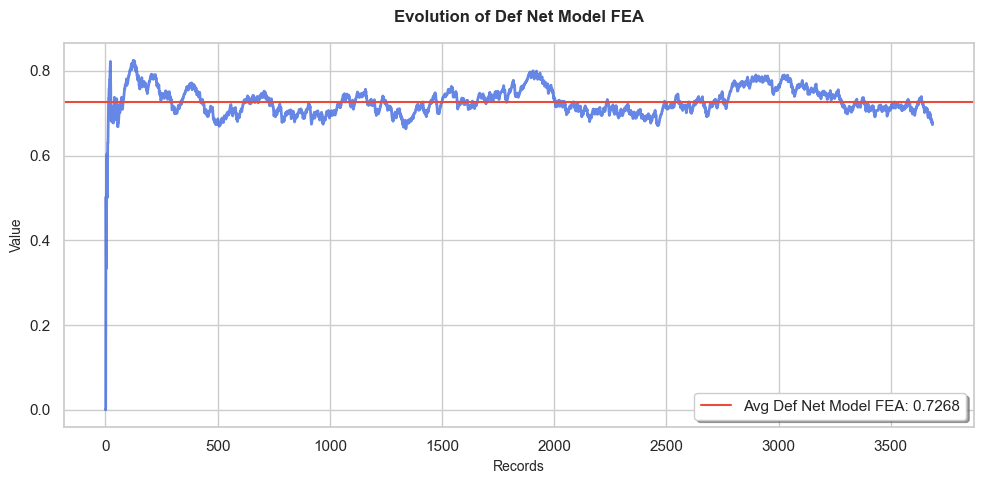

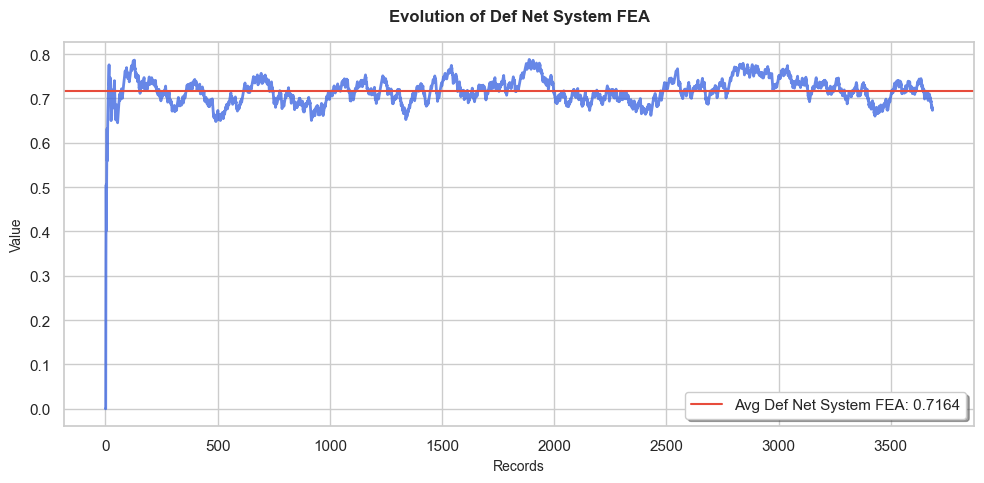

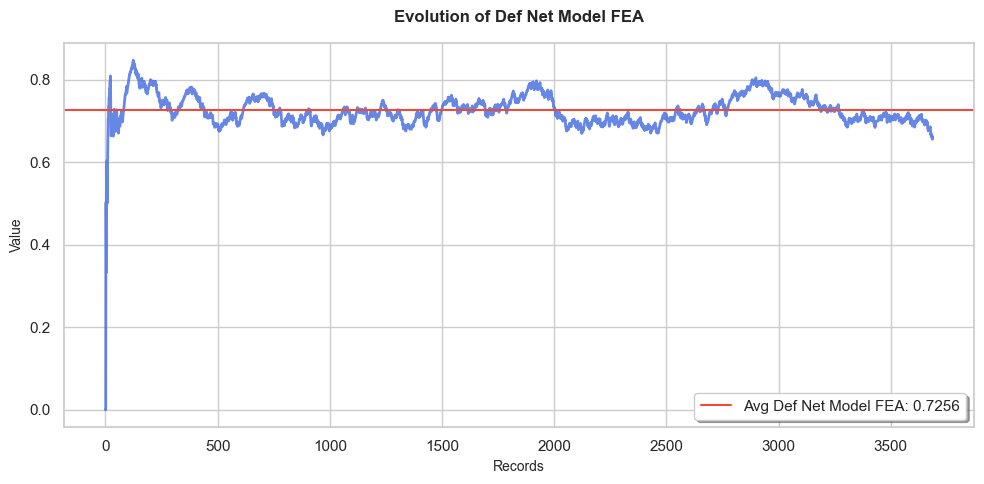

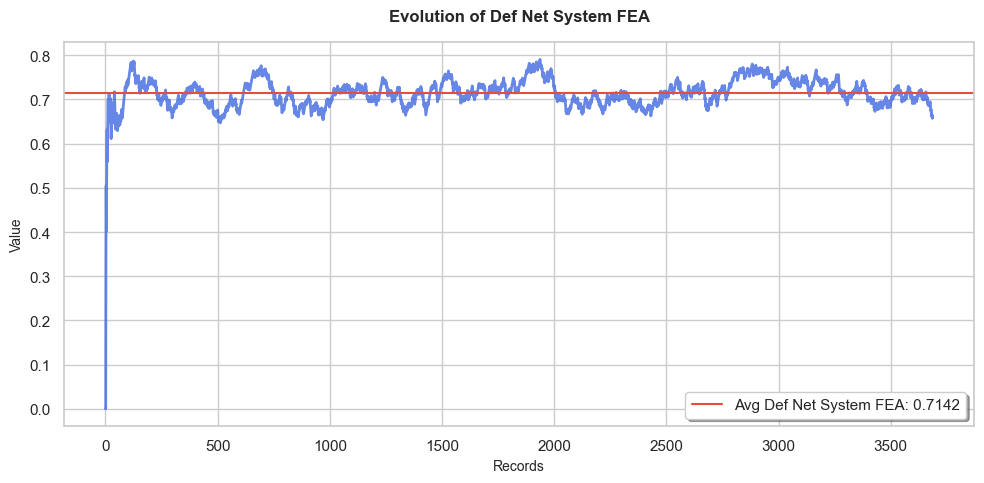

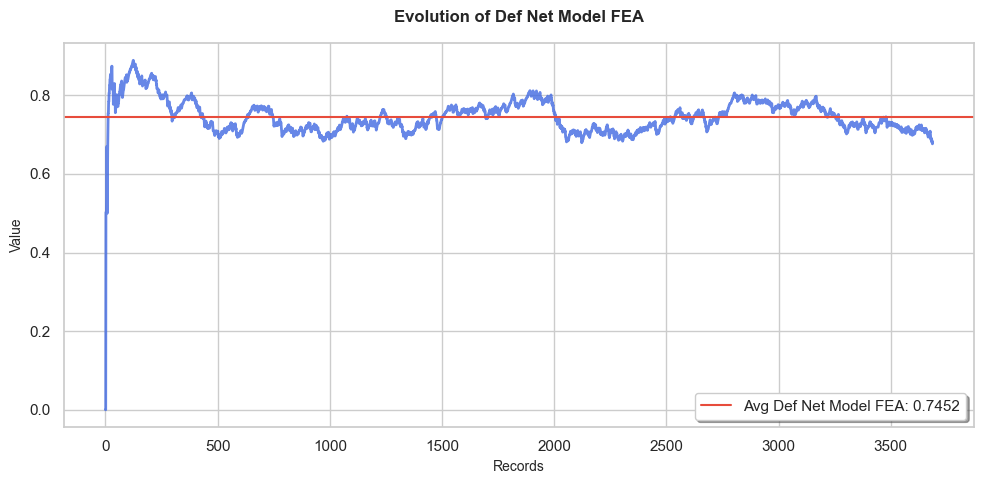

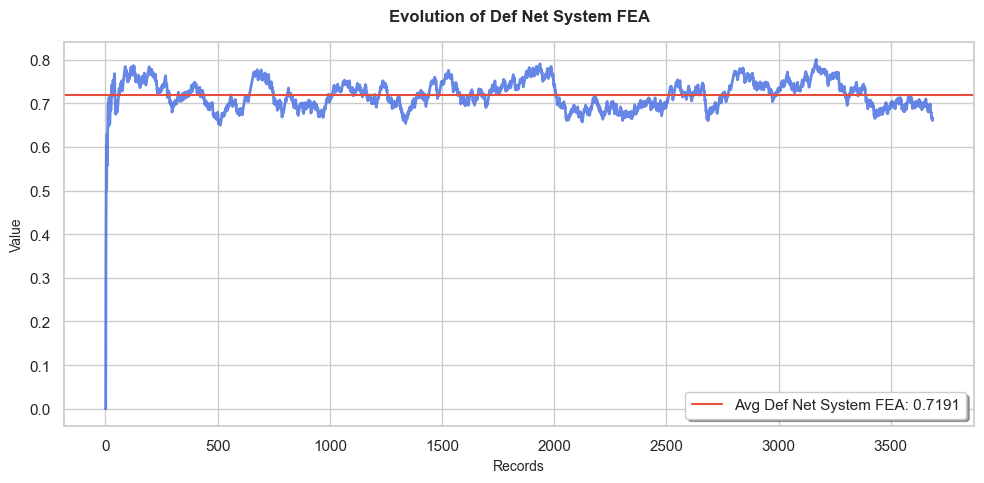

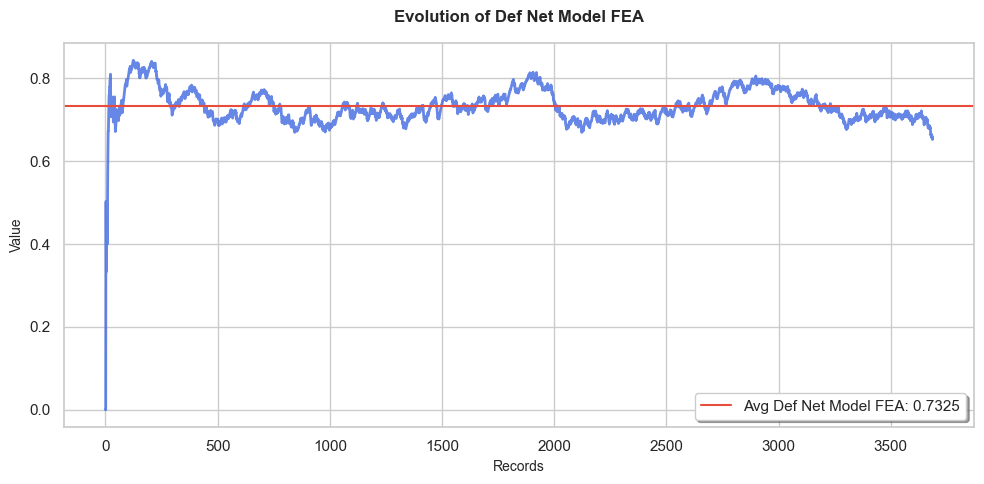

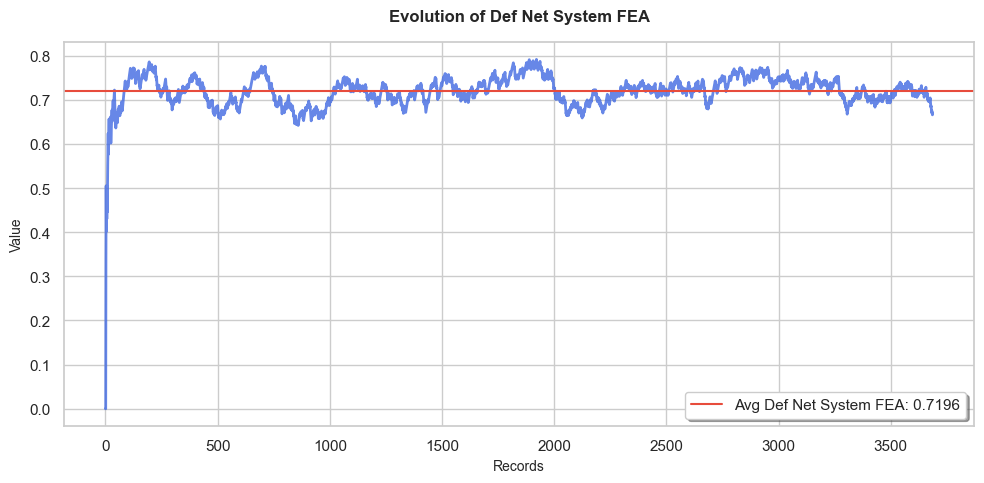

In [33]:
strategy= 'Mao'
betas= ['0.1', '0.3', '0.5', '0.7', '0.9']

res= {}

for beta in betas:
    acc_t_mic_mao= get_mic_data(ds_name, iter, user_name, strategy, beta, mic_metrics)
    res[beta]= acc_t_mic_mao
    plot_sns(acc_t_mic_mao, mic_metrics, mean_required=True)



### Iter 2

In [9]:
iter = 2

user_name= 'accurate_trusting'

hic_metrics= ['ARF_Accuracy', 'ARF_F1', 'ARF_HiC_FEA_machine', 'ARF_HiC_FEA_user', 'ARF_Machine_Confidence']
mic_metrics= ['Def_Net_Model_FEA', 'Def_Net_System_FEA']

#### HIC

In [10]:
acc_t_iter_2= get_hic_data(ds_name, iter, user_name, hic_metrics)


In [11]:
acc_t_iter_2

,ARF_Accuracy,ARF_F1,ARF_HiC_FEA_machine,ARF_HiC_FEA_user,ARF_Machine_Confidence
idx,,,,,
0,0.708785,0.700704,1.000000,0.000000,0.611051
1,0.708785,0.700372,0.995000,0.000000,0.581118
2,0.707701,0.699479,0.990033,0.333333,0.513760
3,0.710954,0.702934,0.985100,0.497500,0.616041
4,0.710412,0.702212,0.980199,0.594020,0.676065
...,...,...,...,...,...
2454,0.709328,0.701425,0.029400,0.029178,0.787542
2455,0.707701,0.699479,0.029501,0.029281,0.530401
2456,0.707701,0.699479,0.029601,0.029384,0.680724


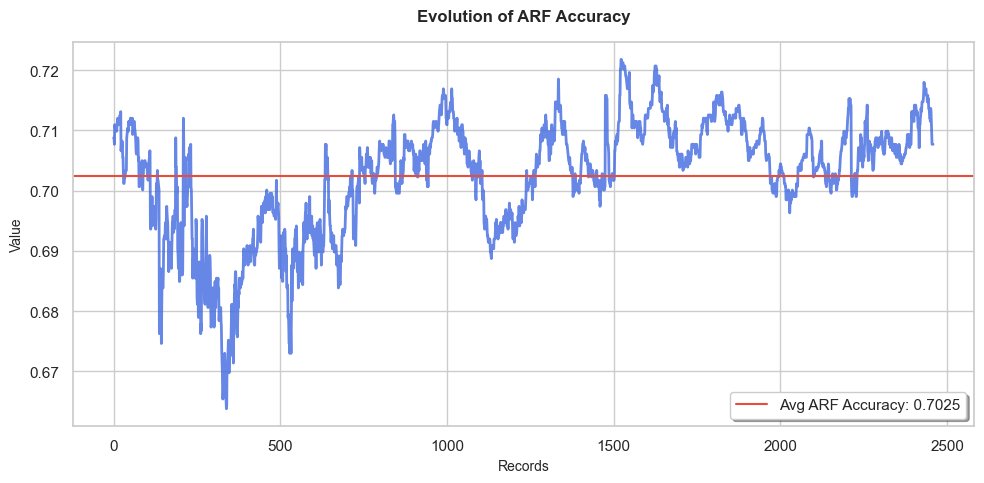

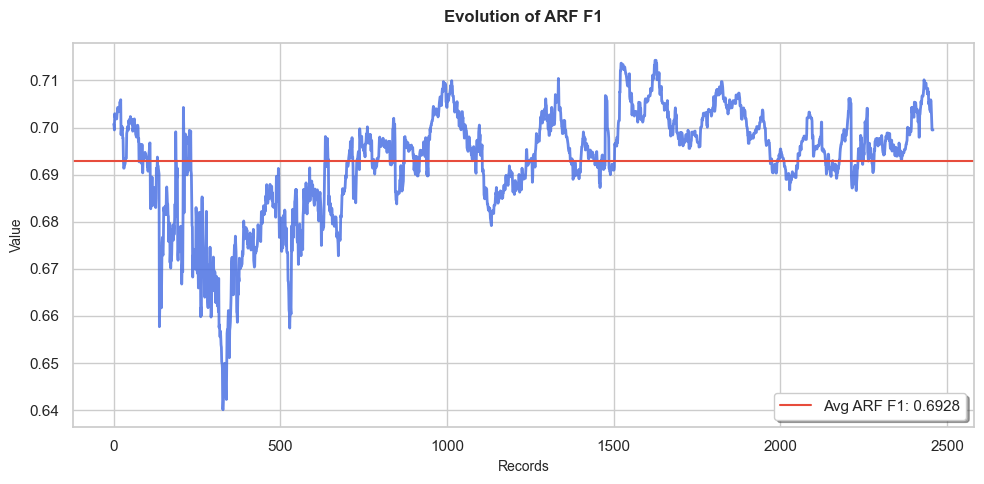

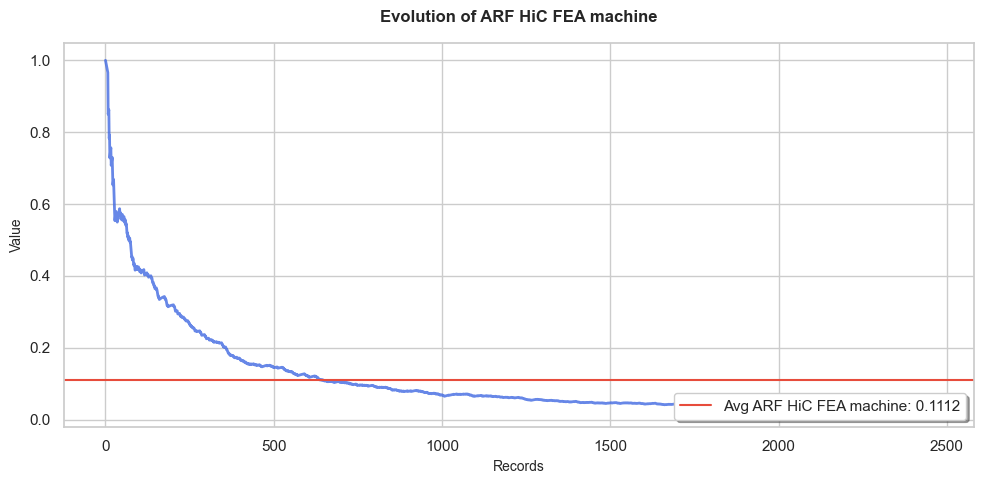

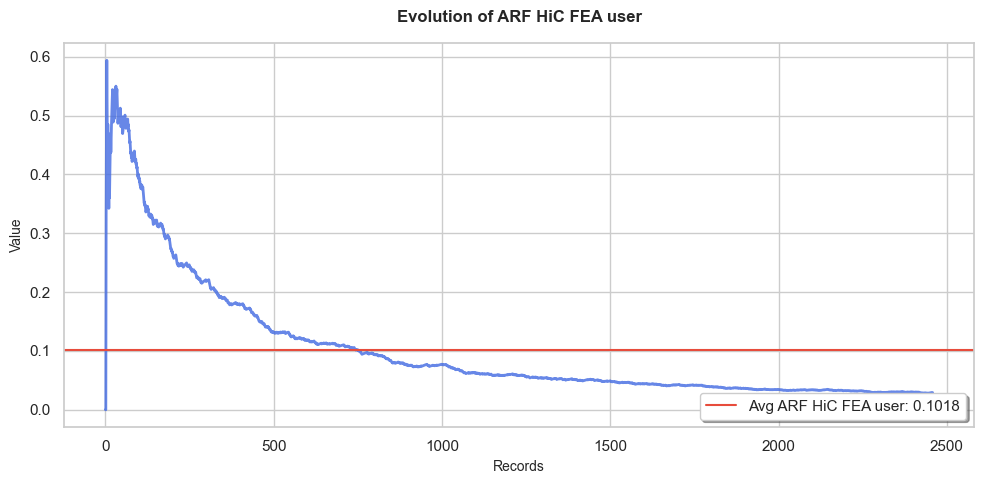

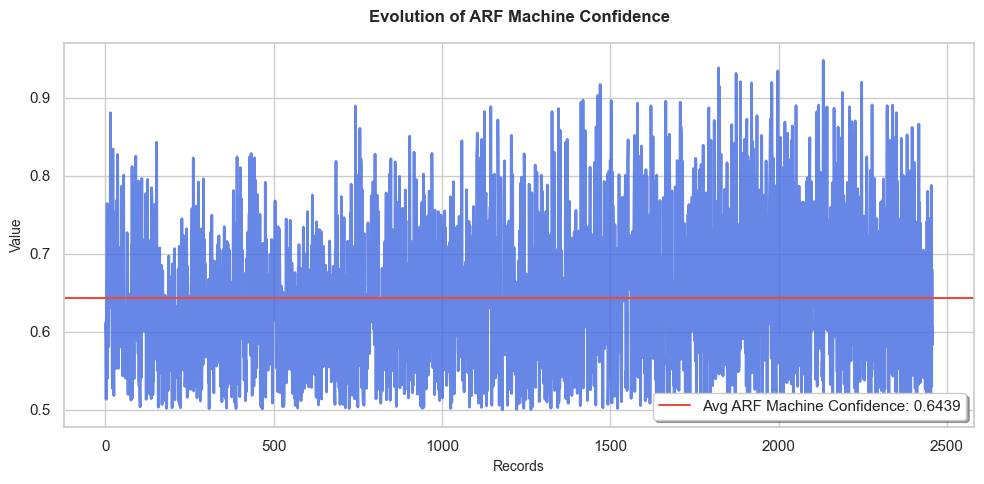

In [12]:
plot_sns(acc_t_iter_2, hic_metrics, mean_required=True)

### Iter 3

In [13]:
iter = 3

user_name= 'accurate_trusting'

hic_metrics= ['ARF_Accuracy', 'ARF_F1', 'ARF_HiC_FEA_machine', 'ARF_HiC_FEA_user', 'ARF_Machine_Confidence']
mic_metrics= ['Def_Net_FEA', 'MiC_FEA']

#### HIC

In [14]:
acc_t_iter_3= get_hic_data(ds_name, iter, user_name, hic_metrics)


In [15]:
acc_t_iter_3

,ARF_Accuracy,ARF_F1,ARF_HiC_FEA_machine,ARF_HiC_FEA_user,ARF_Machine_Confidence
idx,,,,,
0,0.708243,0.699184,1.000000,0.000000,0.658088
1,0.708785,0.699685,0.995000,0.000000,0.660474
2,0.709870,0.700569,0.656700,0.333333,0.529962
3,0.709328,0.699710,0.737600,0.497500,0.665958
4,0.709328,0.699590,0.784179,0.594020,0.574477
...,...,...,...,...,...
2453,0.704989,0.697613,0.028156,0.029073,0.581624
2454,0.704989,0.697613,0.028270,0.029178,0.843237
2455,0.704989,0.697508,0.027976,0.029281,0.567640


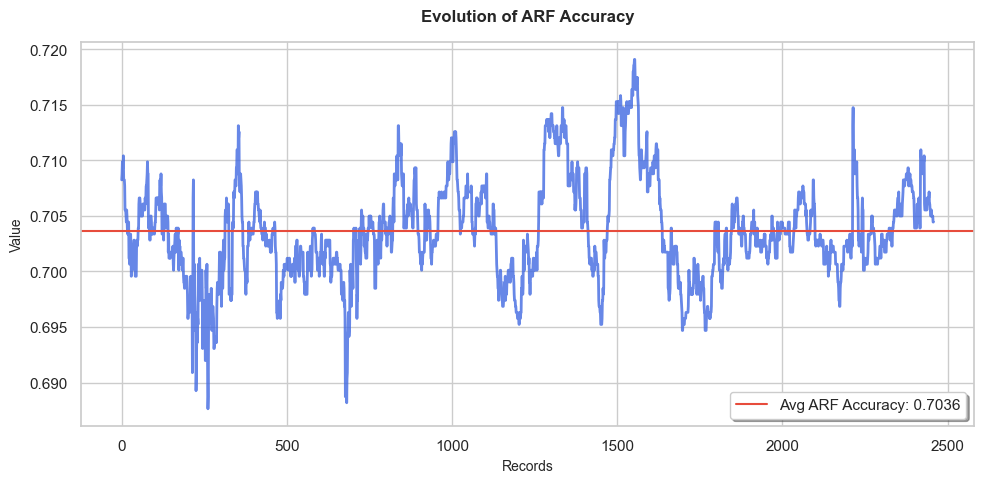

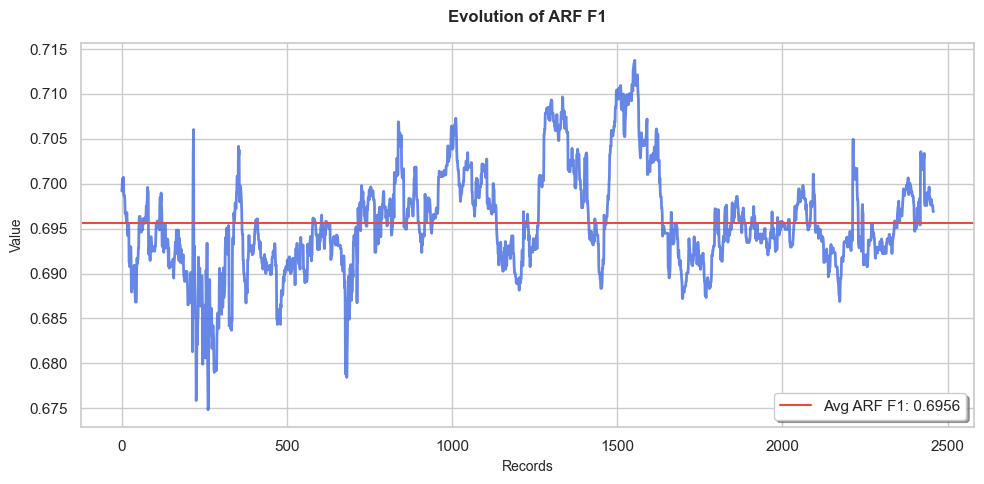

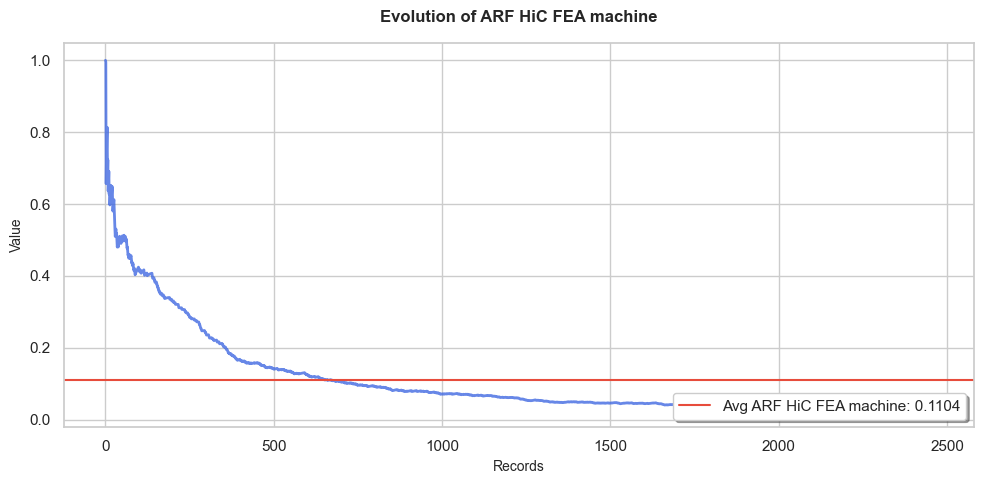

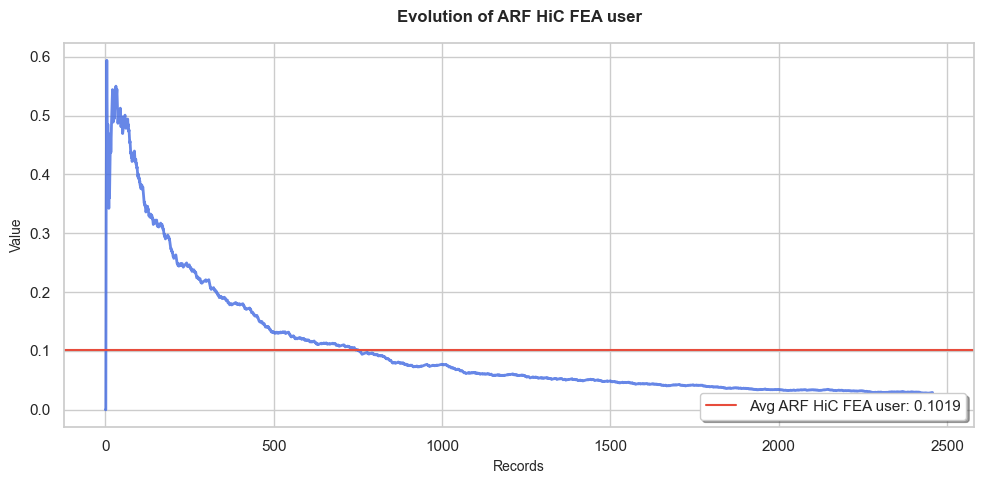

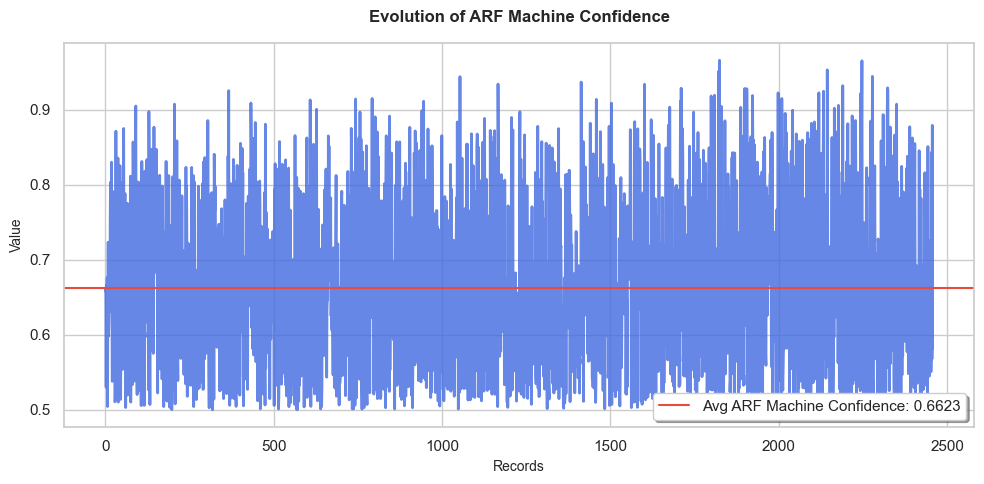

In [16]:
plot_sns(acc_t_iter_3, hic_metrics, mean_required=True)

### HIC FINAL PLOT

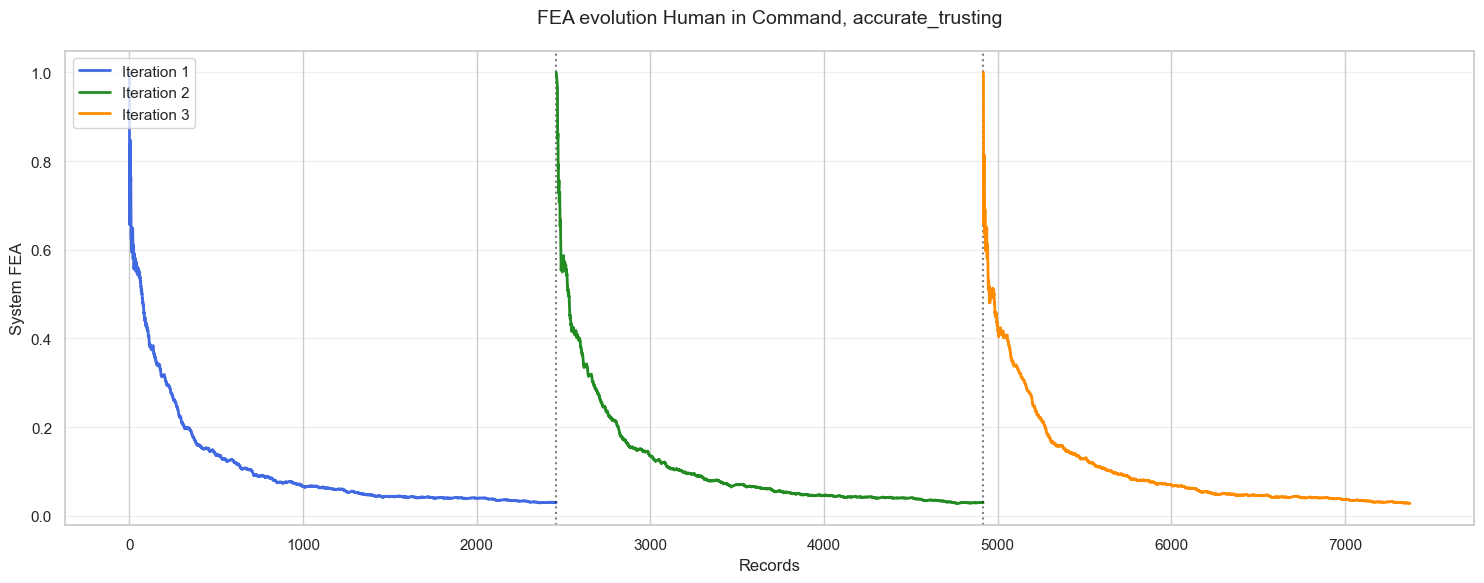

In [ ]:
iter1 = acc_t_iter_1
iter2 = acc_t_iter_2
iter3 = acc_t_iter_3


plt.figure(figsize=(15, 6))

# iter 1
start1 = 0
end1 = len(iter1)
plt.plot(range(start1, end1), iter1['ARF_HiC_FEA_machine'], label='Iteration 1', color='royalblue', linewidth=2)
plt.axvline(x=end1, color='black', linestyle=':', alpha=0.5)

# iter 2
start2 = end1 
end2 = start2 + len(iter2)
plt.plot(range(start2, end2), iter2['ARF_HiC_FEA_machine'], label='Iteration 2', color='forestgreen', linewidth=2)
plt.axvline(x=end2, color='black', linestyle=':', alpha=0.5)


# iter 3
start3 = end2 
end3 = start3 + len(iter3)
plt.plot(range(start3, end3), iter3['ARF_HiC_FEA_machine'], label='Iteration 3', color='darkorange', linewidth=2)


plt.title(f'FEA evolution Human in Command, {user_name}', fontsize=14, pad=20)
plt.xlabel('Records', fontsize=12)
plt.ylabel('System FEA', fontsize=12)

plt.legend(frameon=True, loc='upper left')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## Expert: Inaccurate, Trusting

### Iter 1

In [20]:
iter = 1
user_name= 'inaccurate_trusting'

hic_metrics= ['ARF_Accuracy', 'ARF_F1', 'ARF_HiC_FEA_machine', 'ARF_HiC_FEA_user', 'ARF_Machine_Confidence']
mic_metrics= ['Def_Net_Model_FEA', 'Def_Net_System_FEA']

#### HIC

In [21]:
inacc_t_iter_1= get_hic_data(ds_name, iter, user_name, hic_metrics)


In [22]:
inacc_t_iter_1


,ARF_Accuracy,ARF_F1,ARF_HiC_FEA_machine,ARF_HiC_FEA_user,ARF_Machine_Confidence
idx,,,,,
0,0.706616,0.700140,1.000000,0.000000,0.546907
1,0.703905,0.697515,1.000000,0.000000,0.657446
2,0.703905,0.697515,0.663311,0.336689,0.694570
3,0.705531,0.699031,0.748756,0.505025,0.681450
4,0.707158,0.700247,0.595980,0.606020,0.524515
...,...,...,...,...,...
2454,0.711497,0.702882,0.718669,0.716308,0.767025
2455,0.707701,0.697098,0.721482,0.719145,0.553588
2456,0.707158,0.696600,0.724267,0.721954,0.765778


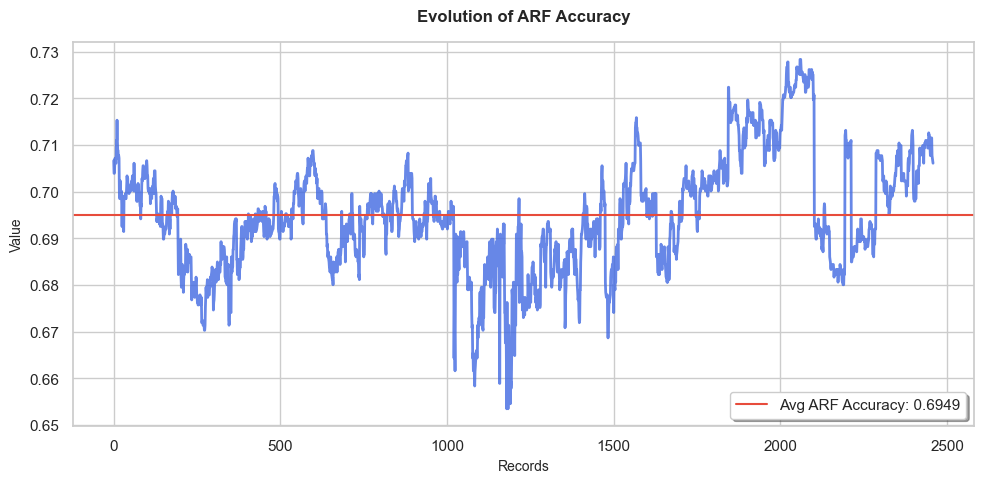

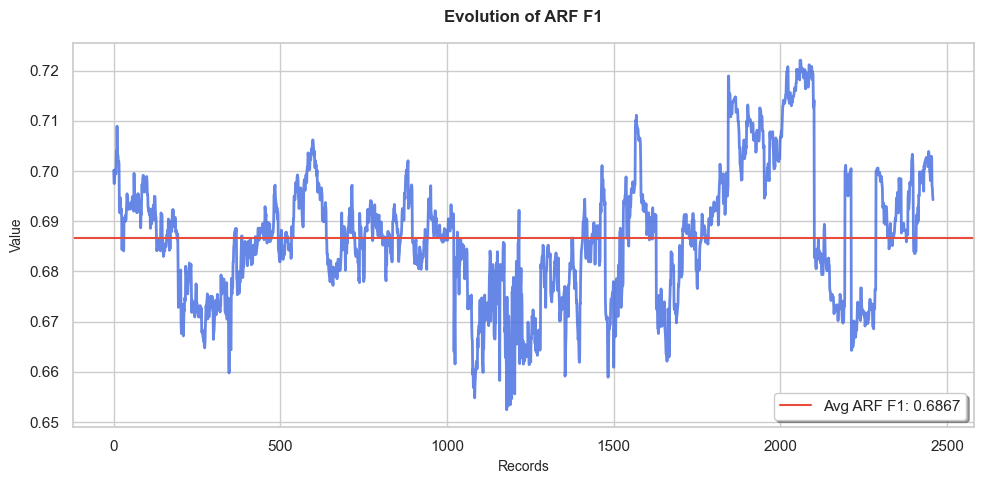

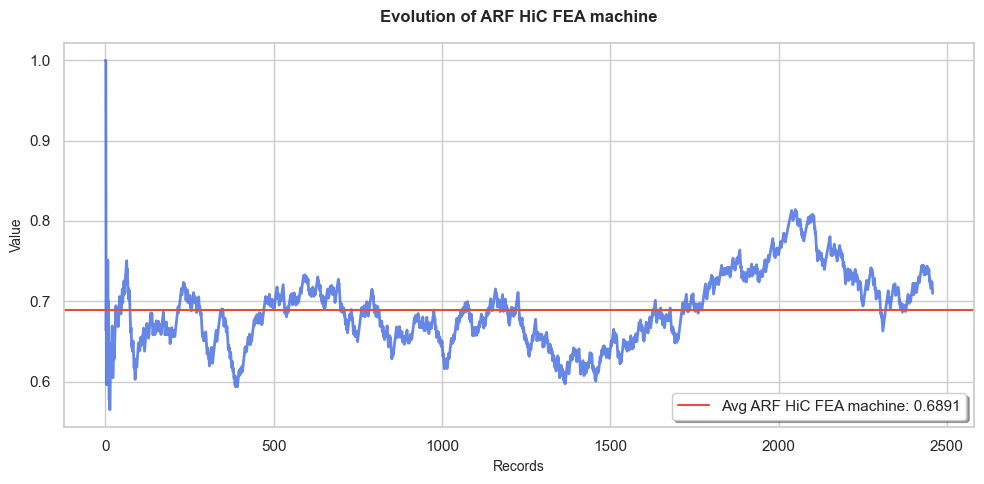

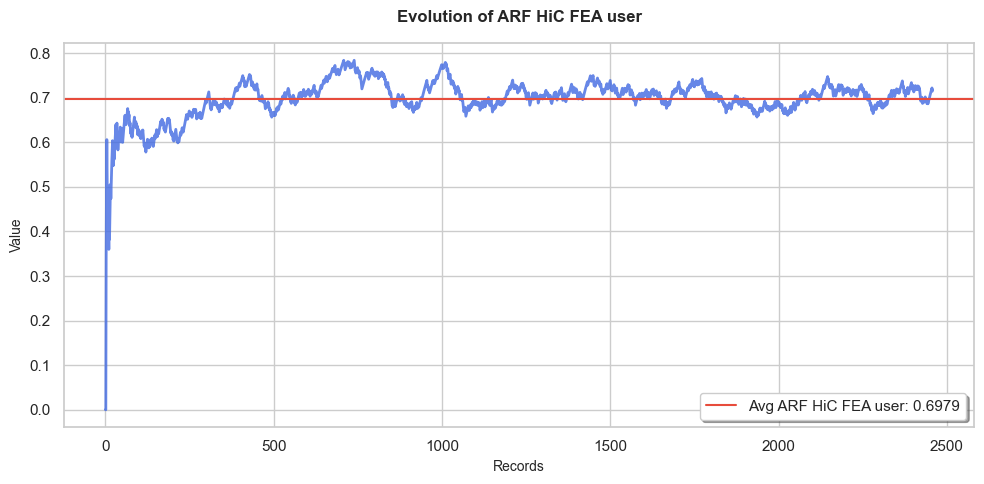

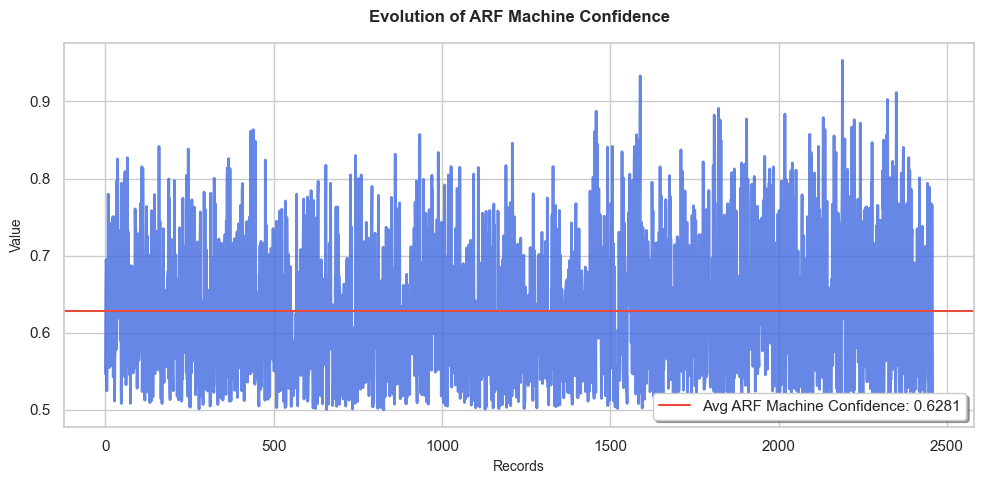

In [23]:
plot_sns(inacc_t_iter_1, hic_metrics, mean_required=True)

#### MIC Confidence Strat

In [24]:
strategy= 'Confidence'
beta= 'None'
inacc_t_mic_conf= get_mic_data(ds_name, iter, user_name, strategy, beta, mic_metrics)


file not found in MIC_res\dutch\iter_1\inaccurate_trusting_Confidence\beta_None\Def_Net_Model_FEA.txt
file not found in MIC_res\dutch\iter_1\inaccurate_trusting_Confidence\beta_None\Def_Net_System_FEA.txt


In [25]:
inacc_t_mic_conf

In [26]:
plot_sns(inacc_t_mic_conf, mic_metrics, mean_required=True)

AttributeError: 'NoneType' object has no attribute 'index'

<Figure size 1000x500 with 0 Axes>

#### MiC Two Stage Deferral Strat

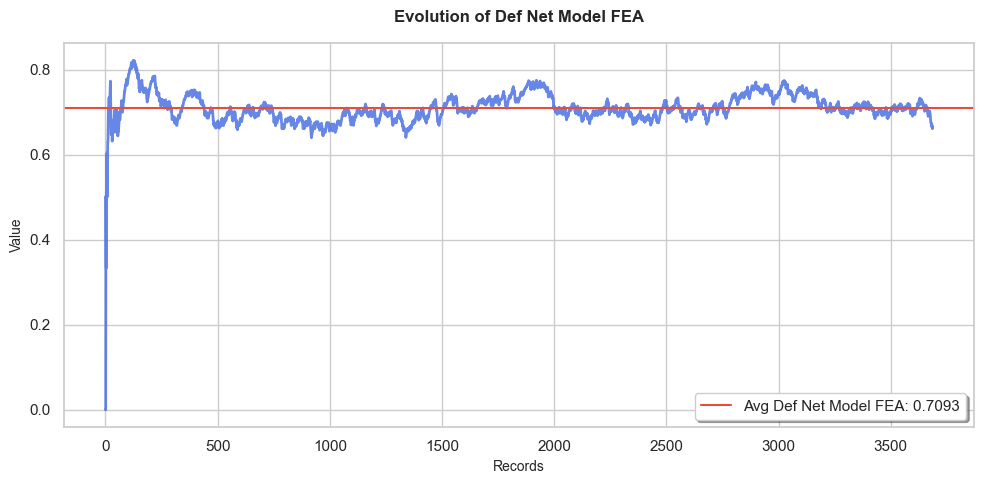

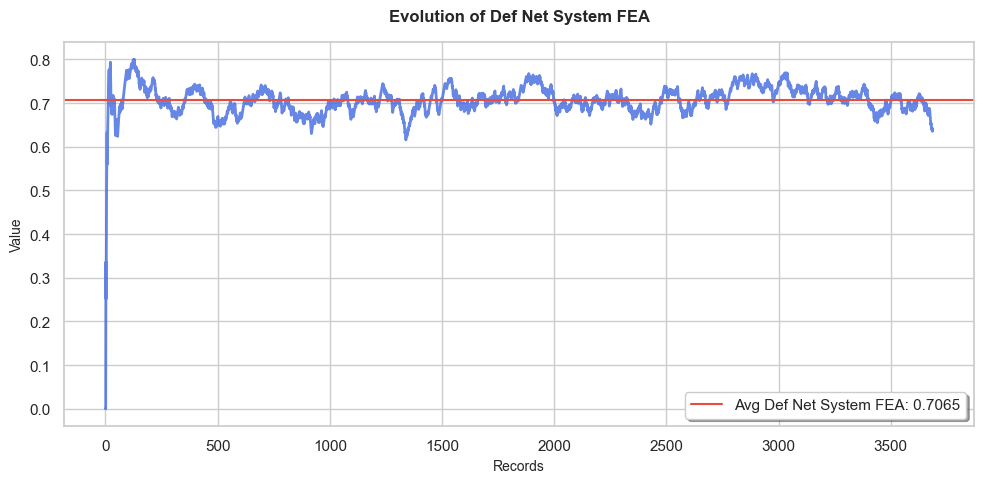

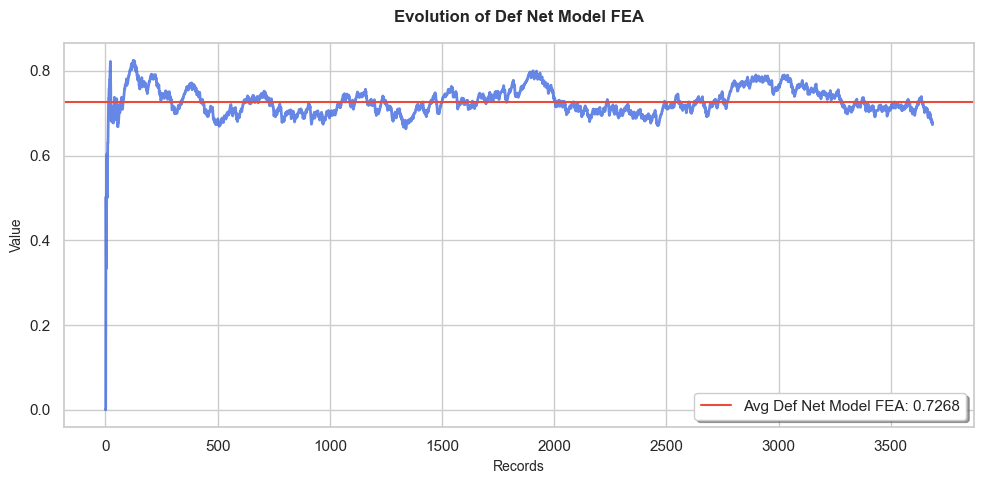

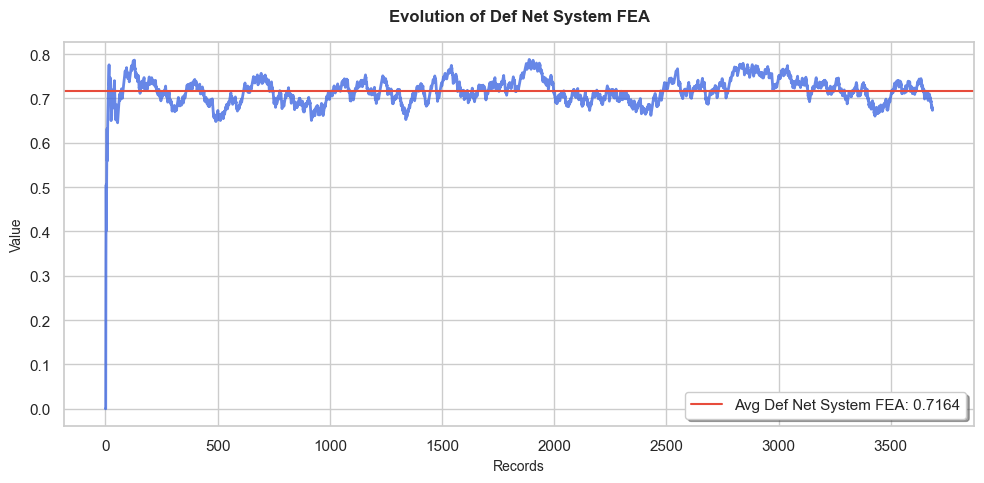

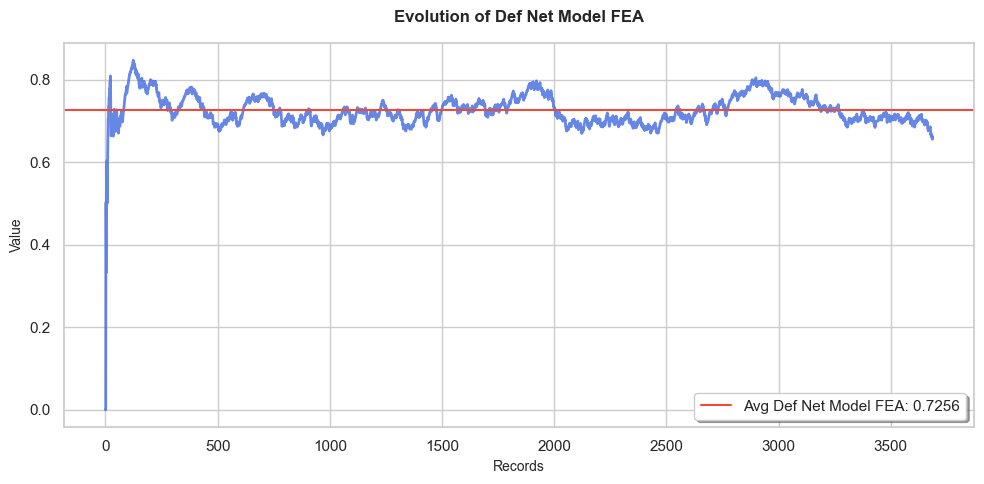

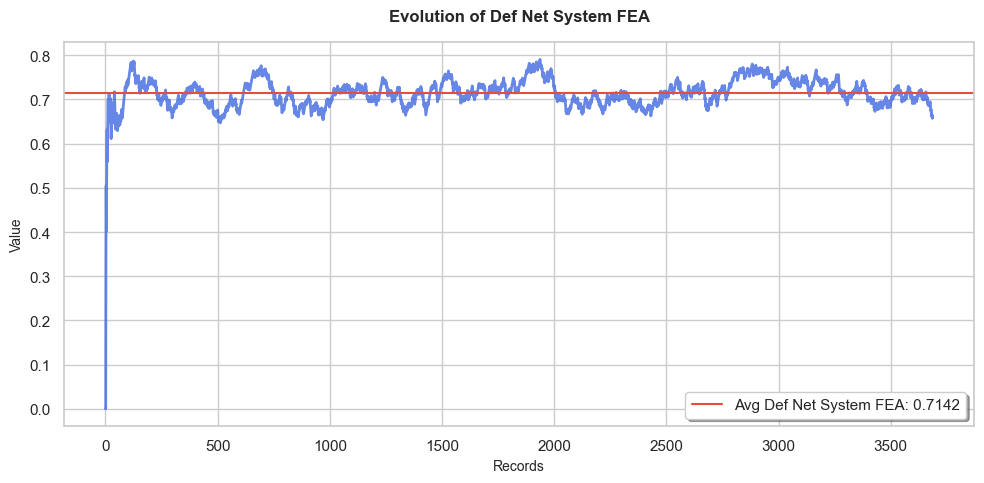

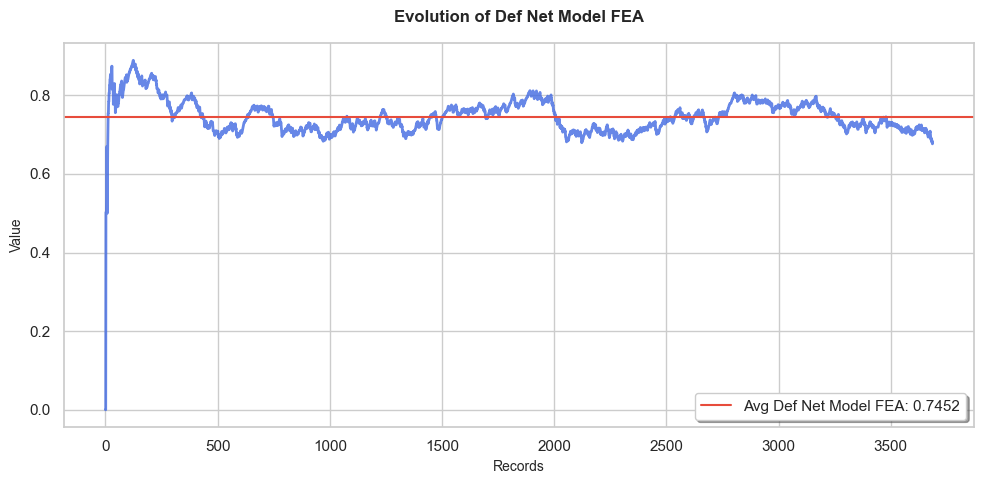

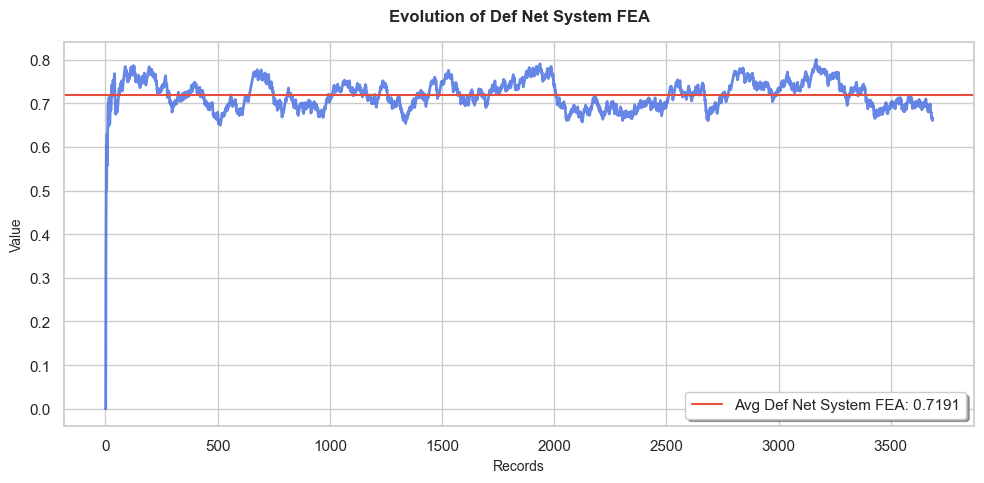

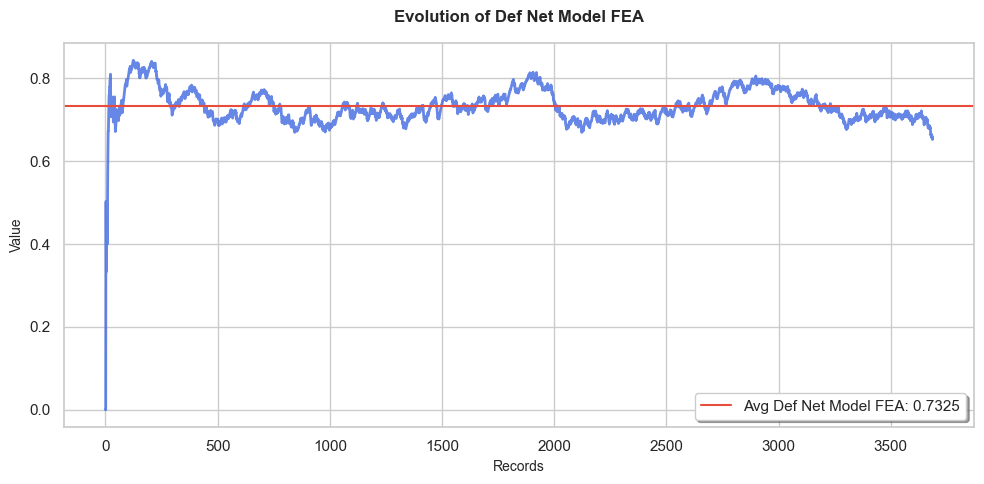

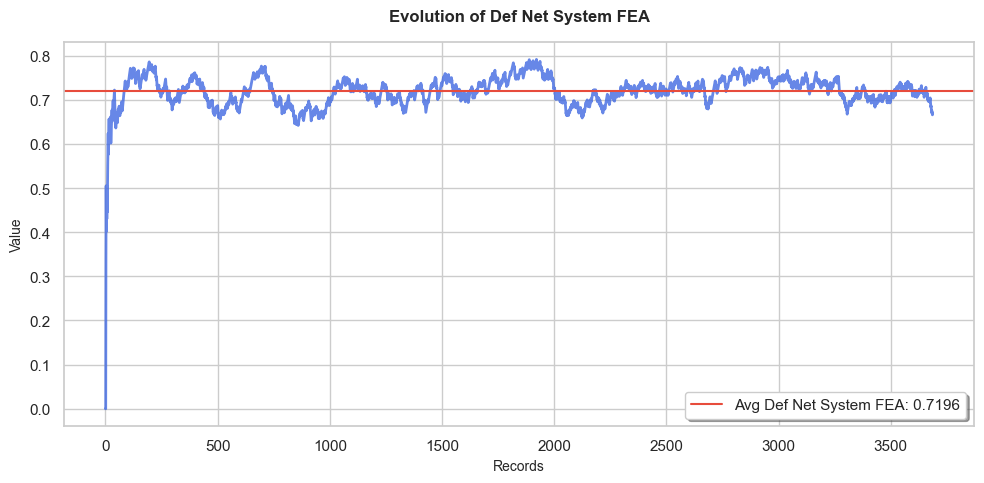

In [ ]:
strategy= 'Mao'
betas= ['0.1', '0.3', '0.5', '0.7', '0.9']

res= {}

for beta in betas:
    inacc_t_mic_mao= get_mic_data(ds_name, iter, user_name, strategy, beta, mic_metrics)
    res[beta]= inacc_t_mic_mao
    plot_sns(inacc_t_mic_mao, mic_metrics, mean_required=True)



### Iter 2

In [27]:
iter = 2

user_name= 'inaccurate_trusting'

hic_metrics= ['ARF_Accuracy', 'ARF_F1', 'ARF_HiC_FEA_machine', 'ARF_HiC_FEA_user', 'ARF_Machine_Confidence']
mic_metrics= ['Def_Net_Model_FEA', 'Def_Net_System_FEA']

#### HIC

In [28]:
inacc_t_iter_2= get_hic_data(ds_name, iter, user_name, hic_metrics)


In [29]:
inacc_t_iter_2

,ARF_Accuracy,ARF_F1,ARF_HiC_FEA_machine,ARF_HiC_FEA_user,ARF_Machine_Confidence
idx,,,,,
0,0.685466,0.673289,1.000000,0.000000,0.669923
1,0.685466,0.673289,1.000000,0.000000,0.686185
2,0.685466,0.673988,0.663311,0.336689,0.524481
3,0.686009,0.674482,0.748756,0.505025,0.505826
4,0.685466,0.673712,0.800020,0.606020,0.514490
...,...,...,...,...,...
2454,0.698482,0.687741,0.720105,0.716308,0.817907
2455,0.697397,0.686617,0.722904,0.719145,0.536324
2456,0.697939,0.687114,0.725675,0.721954,0.851184


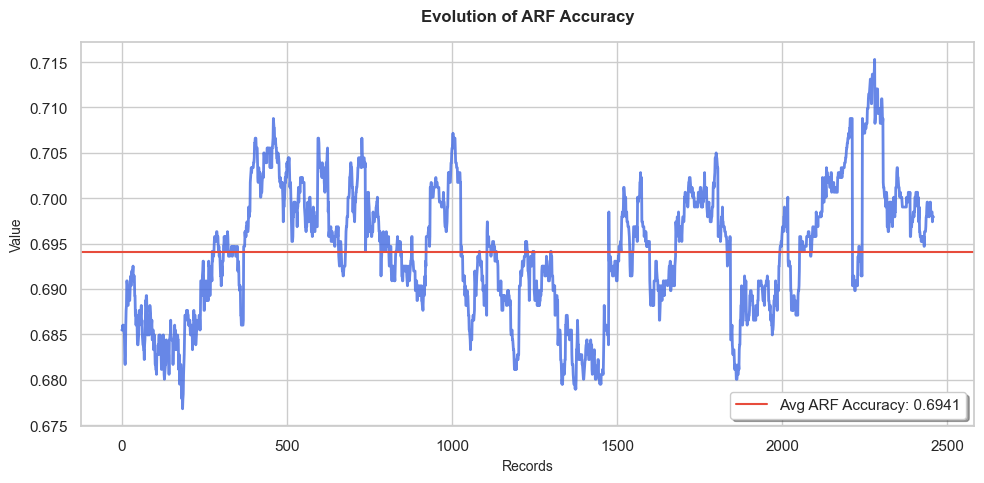

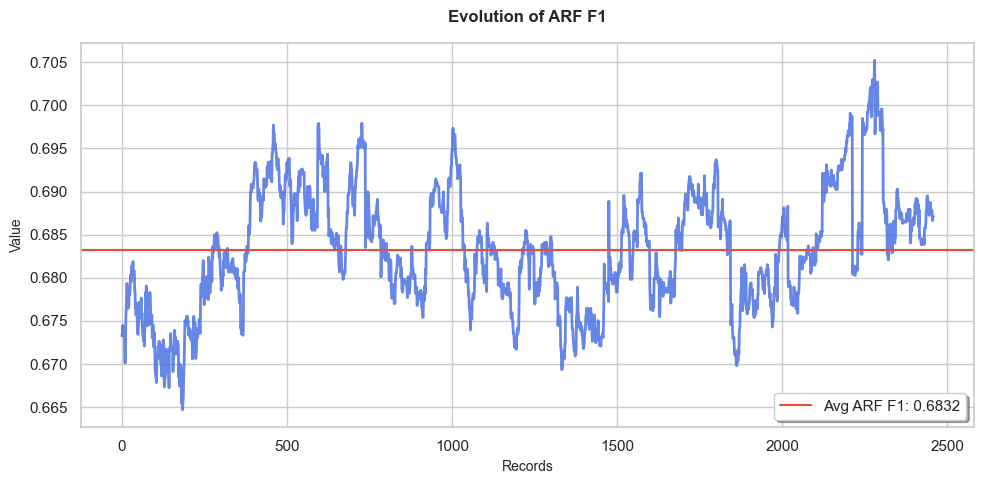

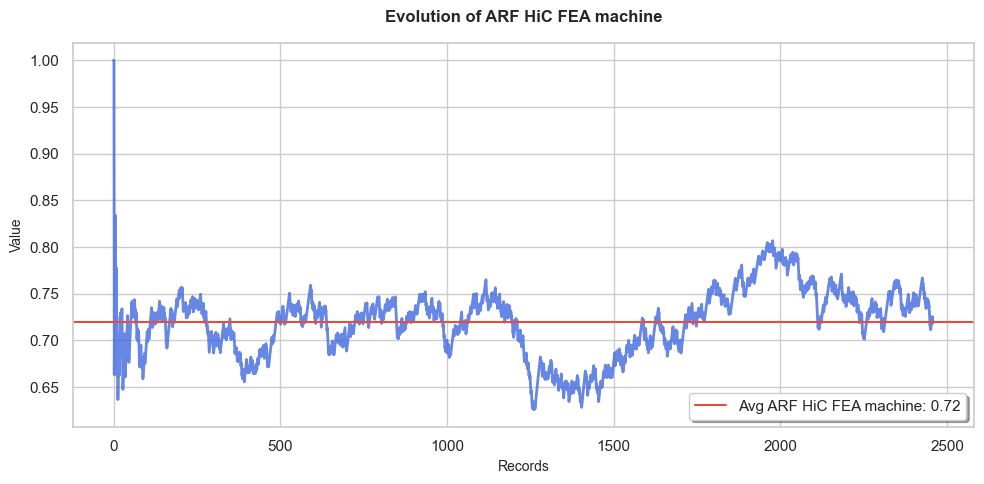

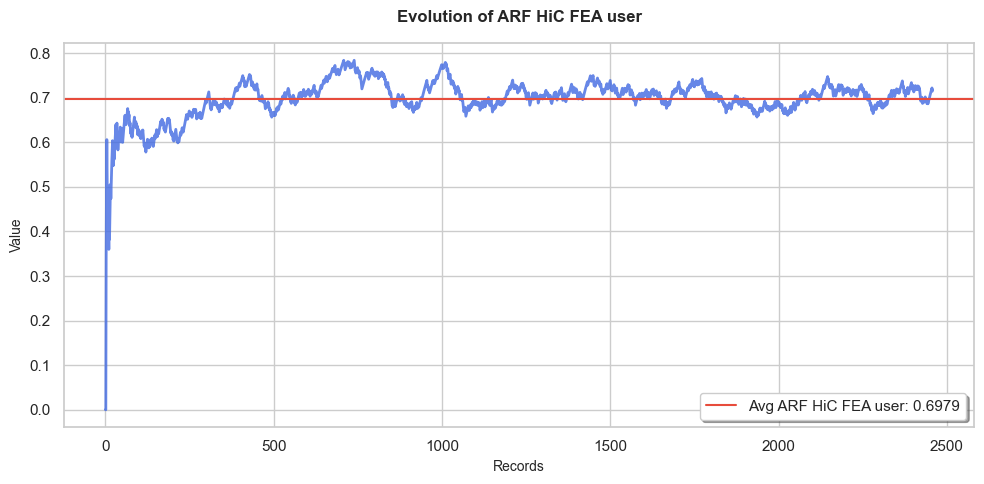

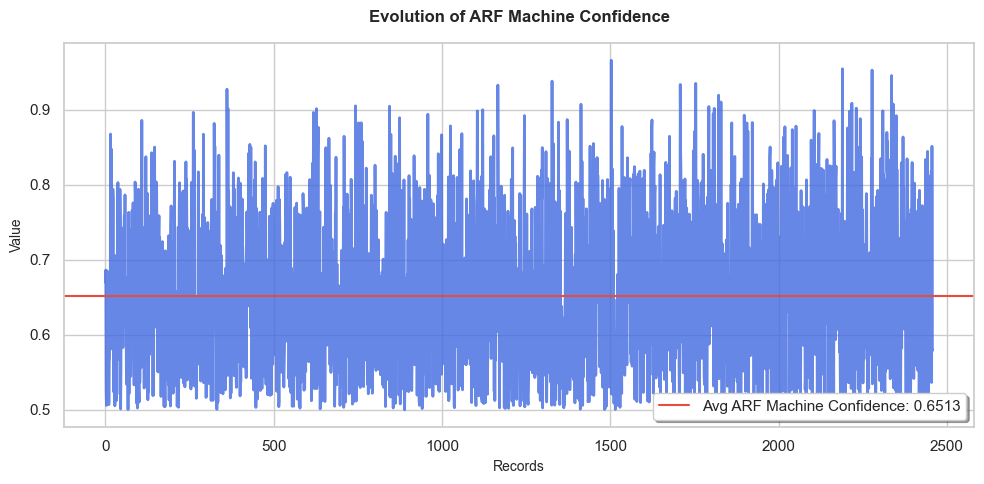

In [30]:
plot_sns(inacc_t_iter_2, hic_metrics, mean_required=True)

### Iter 3

In [31]:
iter = 3

user_name= 'inaccurate_trusting'

hic_metrics= ['ARF_Accuracy', 'ARF_F1', 'ARF_HiC_FEA_machine', 'ARF_HiC_FEA_user', 'ARF_Machine_Confidence']
mic_metrics= ['Def_Net_FEA', 'MiC_FEA']

#### HIC

In [32]:
inacc_t_iter_3= get_hic_data(ds_name, iter, user_name, hic_metrics)


In [33]:
inacc_t_iter_3

,ARF_Accuracy,ARF_F1,ARF_HiC_FEA_machine,ARF_HiC_FEA_user,ARF_Machine_Confidence
idx,,,,,
0,0.696855,0.685187,1.000000,0.000000,0.684225
1,0.696312,0.684692,1.000000,0.000000,0.615162
2,0.696855,0.685858,0.663311,0.336689,0.578249
3,0.696855,0.685592,0.748756,0.505025,0.573090
4,0.696855,0.685726,0.800020,0.606020,0.543926
...,...,...,...,...,...
2453,0.692516,0.683514,0.728904,0.713443,0.597046
2454,0.693059,0.684367,0.731615,0.716308,0.891732
2455,0.691432,0.682517,0.724299,0.719145,0.502866


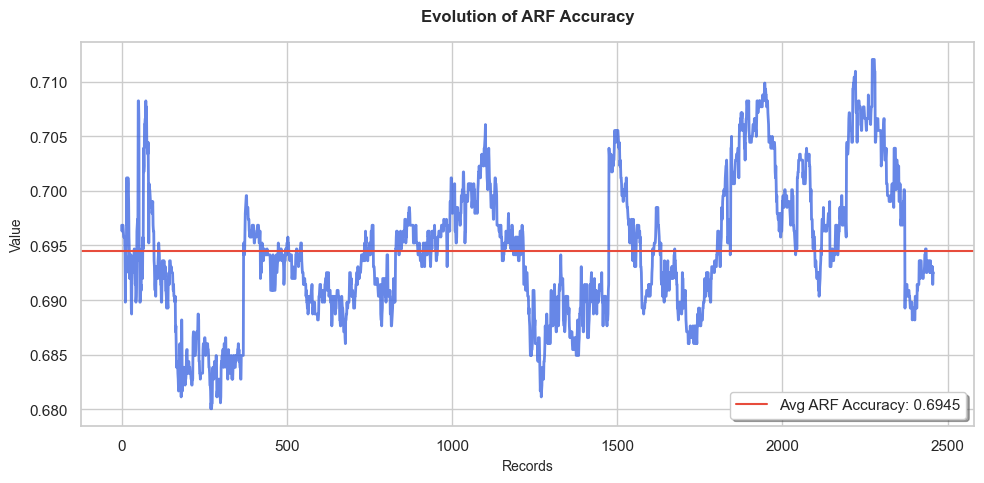

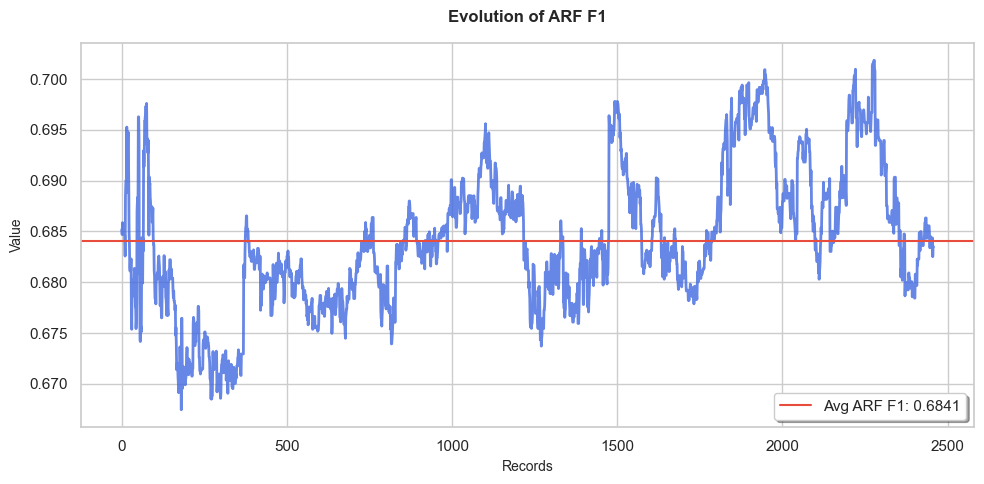

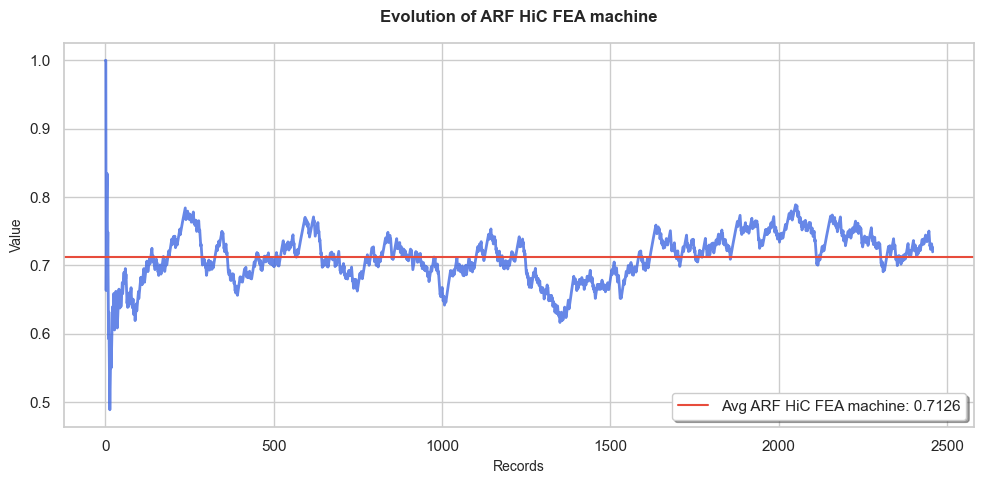

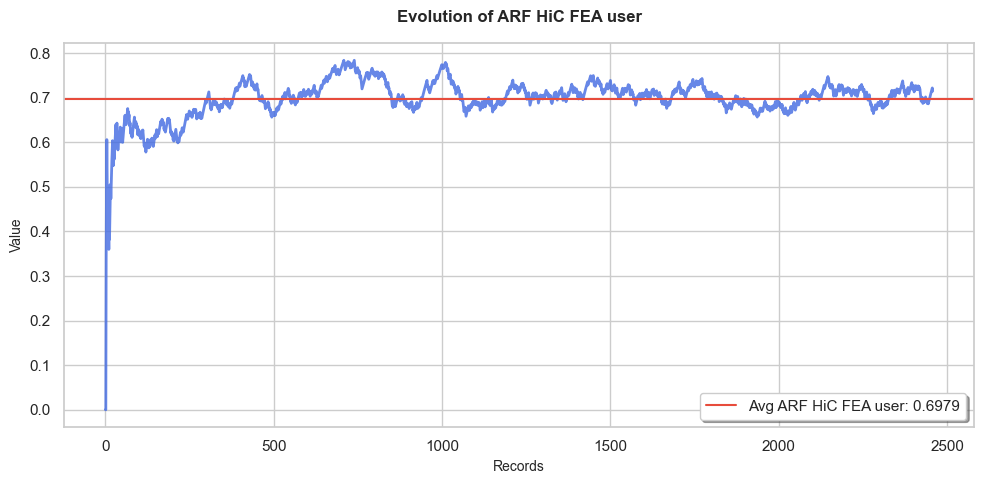

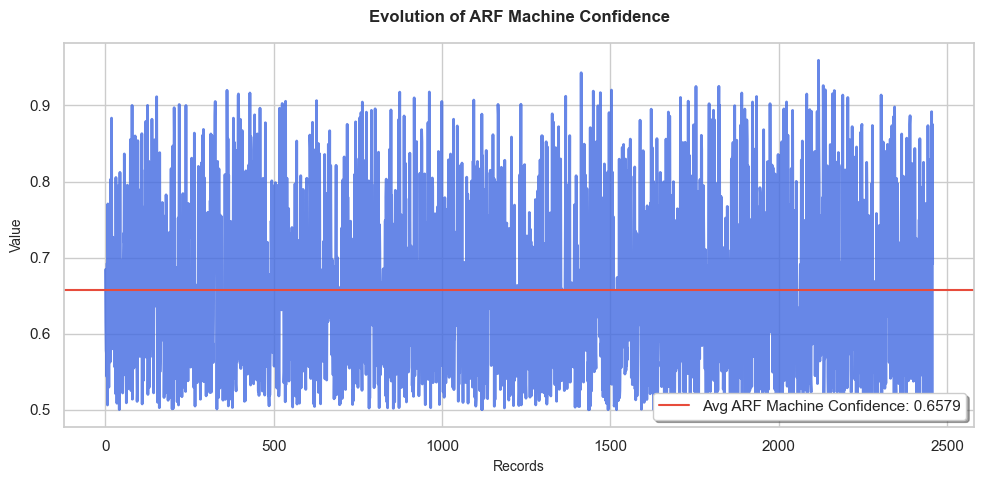

In [34]:
plot_sns(inacc_t_iter_3, hic_metrics, mean_required=True)

### HIC FINAL PLOT

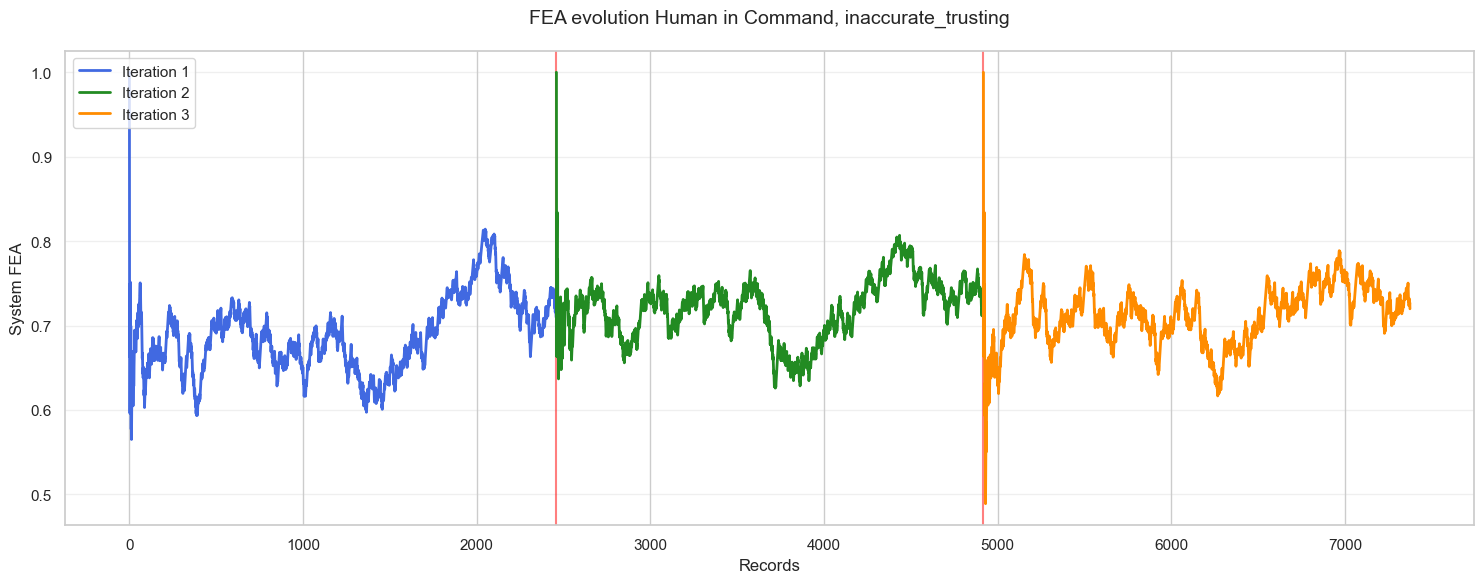

In [ ]:
iter1 = inacc_t_iter_1
iter2 = inacc_t_iter_2

iter3 = inacc_t_iter_3

plt.figure(figsize=(15, 6))

# iter 1
start1 = 0
end1 = len(iter1)
plt.plot(range(start1, end1), iter1['ARF_HiC_FEA_machine'], label='Iteration 1', color='royalblue', linewidth=2)
plt.axvline(x=end1, color='red', linestyle='-', alpha=0.5)

# iter 2
start2 = end1 
end2 = start2 + len(iter2)
plt.plot(range(start2, end2), iter2['ARF_HiC_FEA_machine'], label='Iteration 2', color='forestgreen', linewidth=2)
plt.axvline(x=end2, color='red', linestyle='-', alpha=0.5)

# iter 3
start3 = end2 
end3 = start3 + len(iter3)
plt.plot(range(start3, end3), iter3['ARF_HiC_FEA_machine'], label='Iteration 3', color='darkorange', linewidth=2)


plt.title(f'FEA evolution Human in Command, {user_name}', fontsize=14, pad=20)
plt.xlabel('Records', fontsize=12)
plt.ylabel('System FEA', fontsize=12)
plt.legend(frameon=True, loc='upper left')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()